# Eksperimen SML - Farrel Ghozy Affifudin
## Dataset: Pima Indians Diabetes
## Eksperimen ini mencakup Data Loading, EDA, Preprocessing

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print('Libraries imported successfully')

Libraries imported successfully


## 2. Data Loading

In [2]:
df = pd.read_csv('../diabetes_raw/diabetes_with_headers.csv')

print(f'Dataset shape: {df.shape}')
print(f'Total samples: {df.shape[0]}')
print(f'Total features: {df.shape[1] - 1}')
print(f'Target classes: 2 (0 = Non-Diabetic, 1 = Diabetic)')

df.head(10)

Dataset shape: (768, 9)
Total samples: 768
Total features: 8
Target classes: 2 (0 = Non-Diabetic, 1 = Diabetic)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 3. Exploratory Data Analysis (EDA)

### 3.1 Informasi Dataset

In [3]:
print('=== Dataset Info ===')
df.info()
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Duplicated Rows ===')
print(f'Duplicated: {df.duplicated().sum()}')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigre

### 3.2 Statistik Deskriptif

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### 3.3 Distribusi Target

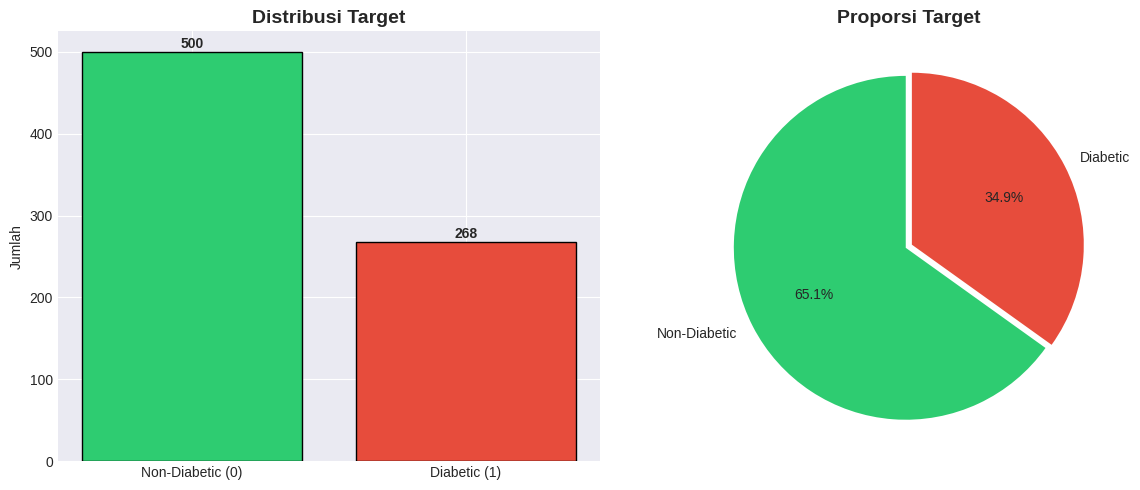

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['Outcome'].value_counts()
axes[0].bar(['Non-Diabetic (0)', 'Diabetic (1)'], target_counts.values,
           color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribusi Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['Non-Diabetic', 'Diabetic'],
           autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
           startangle=90, explode=(0.02, 0.02))
axes[1].set_title('Proporsi Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../preprocessing/target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.4 Deteksi Missing Values (Nol yang Tidak Valid)

Jumlah nilai 0 (invalid) per kolom:
  Glucose                  :    5 (0.65%)
  BloodPressure            :   35 (4.56%)
  SkinThickness            :  227 (29.56%)
  Insulin                  :  374 (48.70%)
  BMI                      :   11 (1.43%)


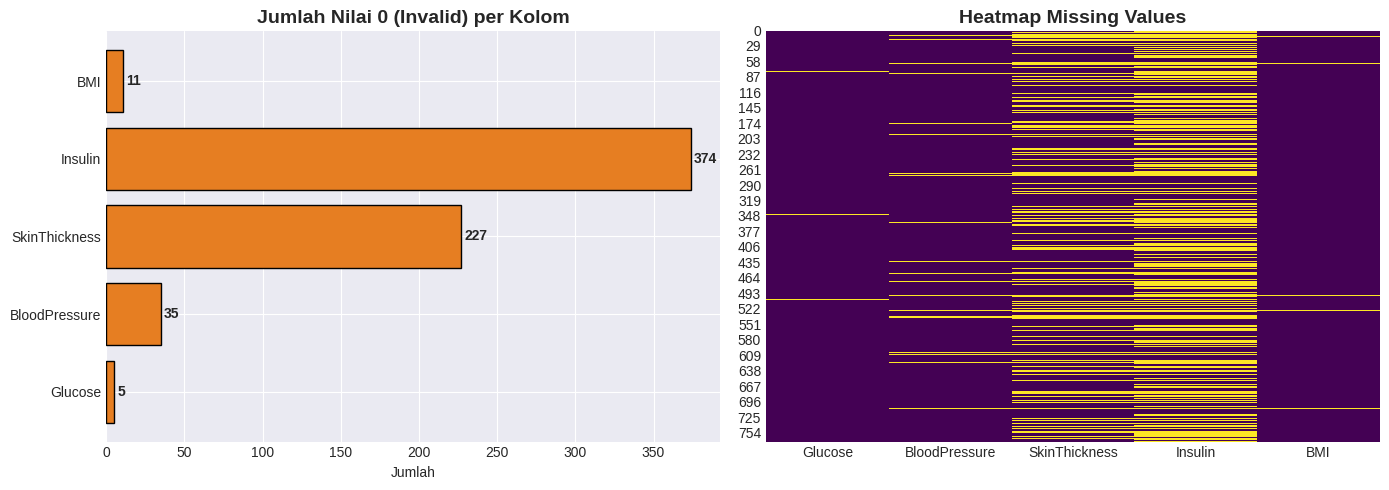

In [6]:
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Jumlah nilai 0 (invalid) per kolom:')
for col in columns_with_zero:
    zero_count = (df[col] == 0).sum()
    zero_pct = (zero_count / len(df)) * 100
    print(f'  {col:25s}: {zero_count:4d} ({zero_pct:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

zero_counts = [(df[col] == 0).sum() for col in columns_with_zero]
axes[0].barh(columns_with_zero, zero_counts, color='#e67e22', edgecolor='black')
axes[0].set_title('Jumlah Nilai 0 (Invalid) per Kolom', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah')
for i, v in enumerate(zero_counts):
    axes[0].text(v + 2, i, str(v), va='center', fontweight='bold')

missing_data = df[columns_with_zero].copy()
missing_data.replace(0, np.nan, inplace=True)
sns.heatmap(missing_data.isnull(), cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Heatmap Missing Values', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../preprocessing/missing_values.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.5 Analisis Korelasi

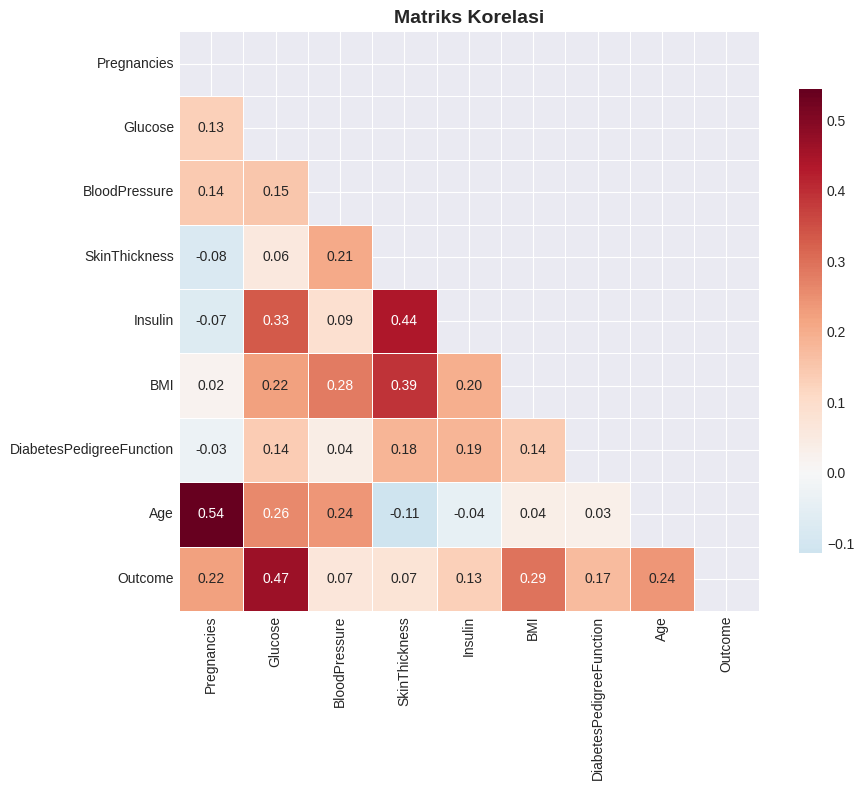


Korelasi dengan Outcome (dari tertinggi ke terendah):
  Glucose                       : +0.4666
  BMI                           : +0.2927
  Age                           : +0.2384
  Pregnancies                   : +0.2219
  DiabetesPedigreeFunction      : +0.1738
  Insulin                       : +0.1305
  SkinThickness                 : +0.0748
  BloodPressure                 : +0.0651


In [7]:
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
           center=0, square=True, linewidths=0.5,
           cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../preprocessing/correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nKorelasi dengan Outcome (dari tertinggi ke terendah):')
corr_with_outcome = corr['Outcome'].sort_values(ascending=False)
for col, val in corr_with_outcome.items():
    if col != 'Outcome':
        print(f'  {col:30s}: {val:+.4f}')

### 3.6 Distribusi Fitur

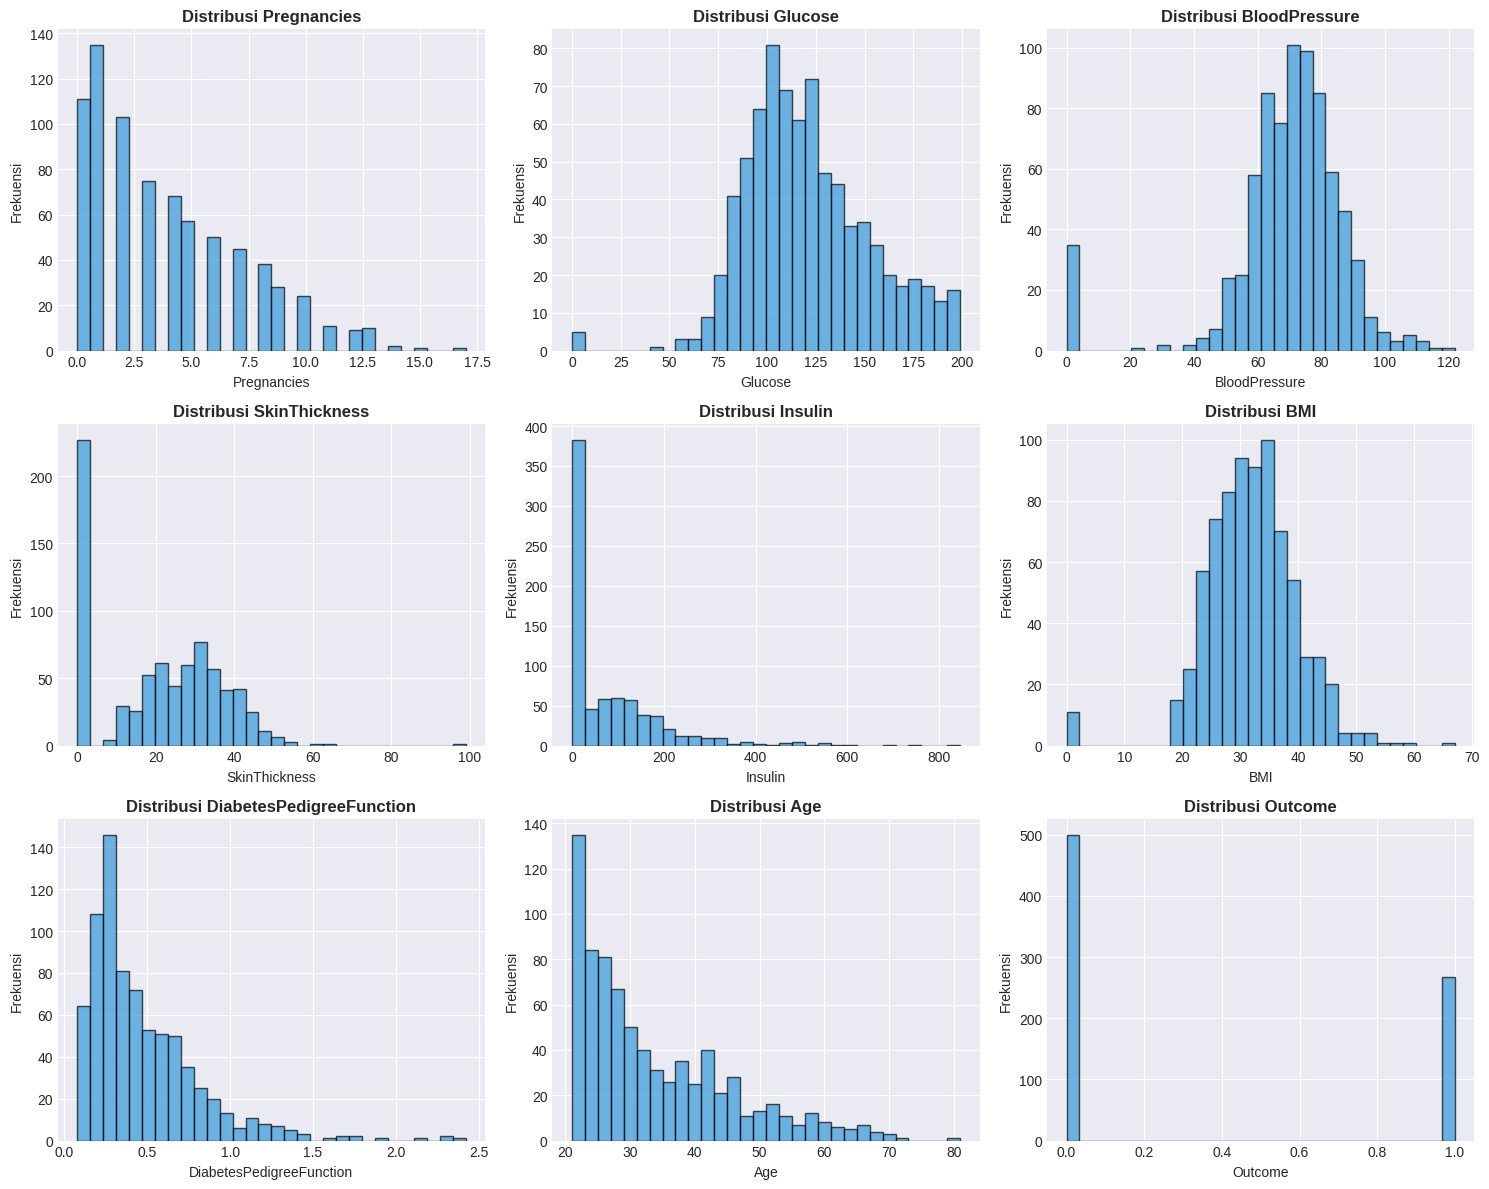

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='#3498db')
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('../preprocessing/feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.7 Boxplot per Fitur

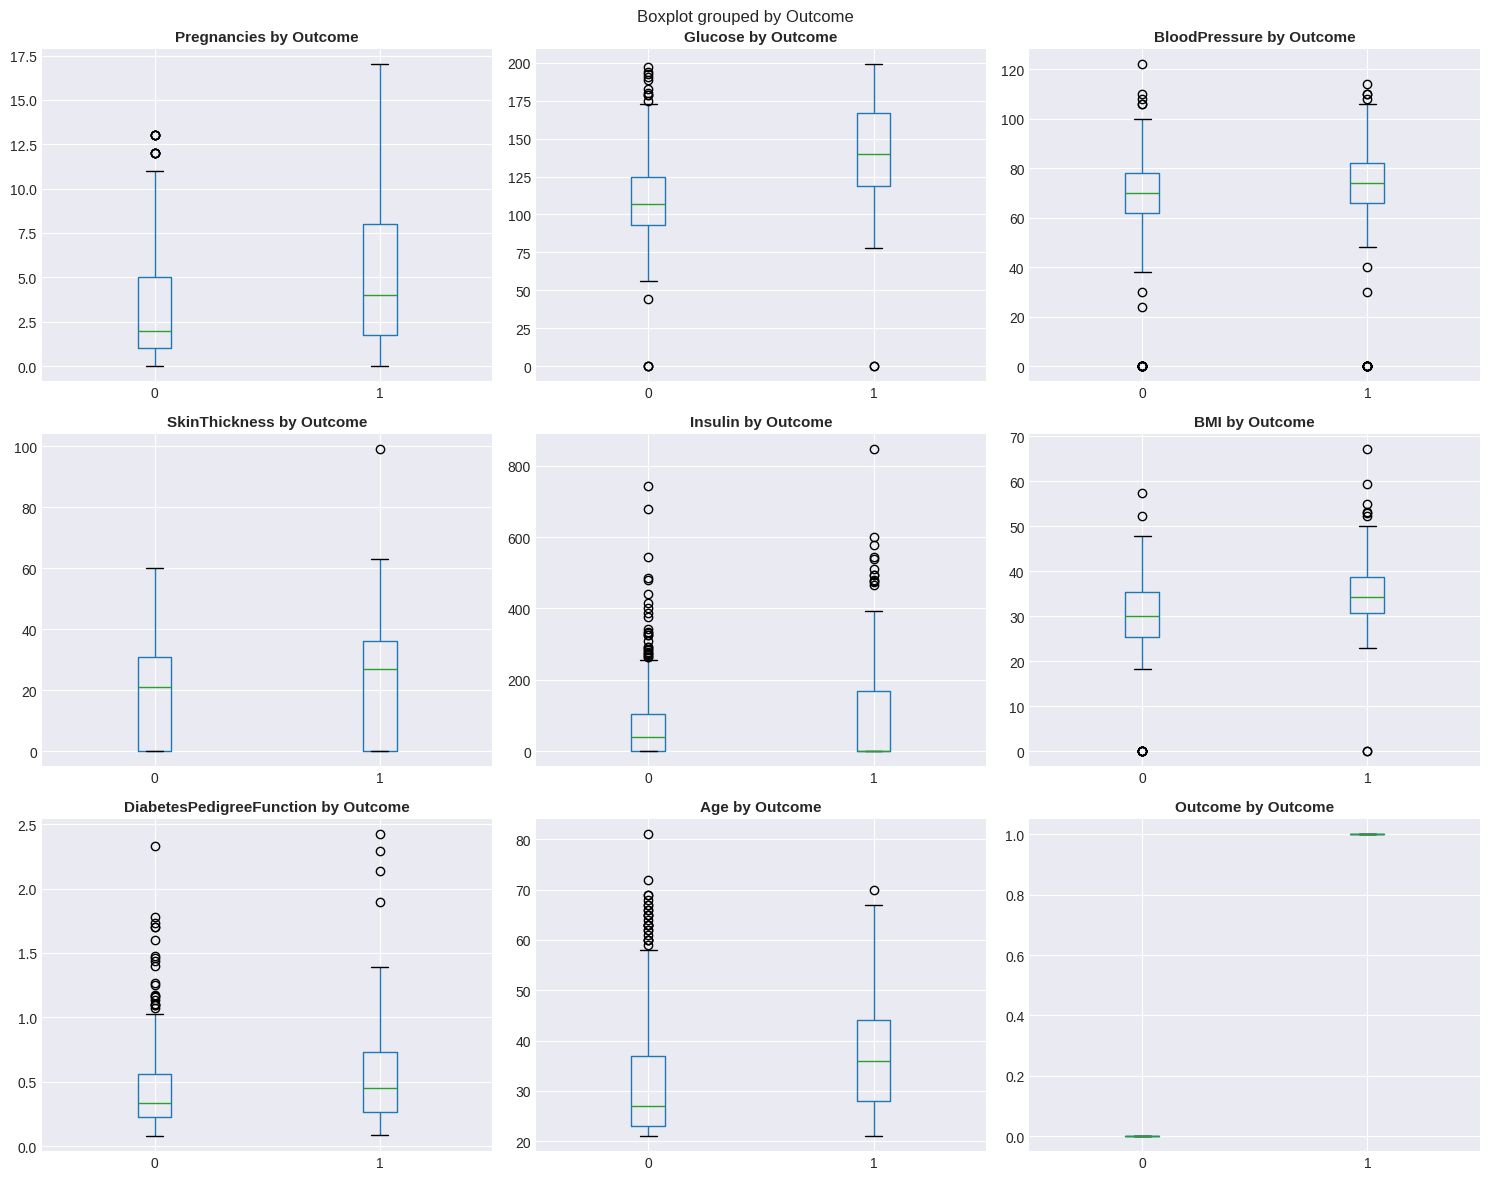

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    df.boxplot(column=col, by='Outcome', ax=axes[i])
    axes[i].set_title(f'{col} by Outcome', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('../preprocessing/boxplot_by_outcome.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Preprocessing

### 4.1 Handle Missing Values (Replace 0 with Median)

In [10]:
df_clean = df.copy()

for col in columns_with_zero:
    median_val = df_clean[col][df_clean[col] != 0].median()
    df_clean[col] = df_clean[col].replace(0, median_val)
    print(f'{col:25s}: Nilai 0 diganti dengan median = {median_val:.2f}')

print(f'\nAfter cleaning - total zeros per column:')
for col in columns_with_zero:
    print(f'  {col:25s}: {(df_clean[col] == 0).sum()}')

Glucose                  : Nilai 0 diganti dengan median = 117.00
BloodPressure            : Nilai 0 diganti dengan median = 72.00
SkinThickness            : Nilai 0 diganti dengan median = 29.00
Insulin                  : Nilai 0 diganti dengan median = 125.00
BMI                      : Nilai 0 diganti dengan median = 32.30

After cleaning - total zeros per column:
  Glucose                  : 0
  BloodPressure            : 0
  SkinThickness            : 0
  Insulin                  : 0
  BMI                      : 0


### 4.2 Feature Scaling (StandardScaler)

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature_names = X.columns.tolist()

print(f'X_train shape: {X_train_scaled.shape}')
print(f'X_test shape: {X_test_scaled.shape}')
print(f'y_train distribution: {pd.Series(y_train).value_counts().to_dict()}')
print(f'y_test distribution: {pd.Series(y_test).value_counts().to_dict()}')

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train distribution: {0: 400, 1: 214}
y_test distribution: {0: 100, 1: 54}


### 4.3 Simpan Hasil Preprocessing

In [12]:
import joblib
import os

os.makedirs('diabetes_preprocessing', exist_ok=True)

train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
train_df['Outcome'] = y_train.values

test_df = pd.DataFrame(X_test_scaled, columns=feature_names)
test_df['Outcome'] = y_test.values

train_df.to_csv('diabetes_preprocessing/train.csv', index=False)
test_df.to_csv('diabetes_preprocessing/test.csv', index=False)
joblib.dump(scaler, 'diabetes_preprocessing/scaler.pkl')

all_data = df_clean.copy()
all_data_scaled = pd.DataFrame(
    scaler.fit_transform(all_data.drop('Outcome', axis=1)),
    columns=feature_names
)
all_data_scaled['Outcome'] = all_data['Outcome'].values
all_data_scaled.to_csv('diabetes_preprocessing/diabetes_clean.csv', index=False)

print('Files saved to diabetes_preprocessing/:') 
for f in os.listdir('diabetes_preprocessing'):
    print(f'  - {f}')

Files saved to diabetes_preprocessing/:
  - zero_values.png
  - diabetes_clean.csv
  - scaler.pkl
  - correlation_matrix.png
  - train.csv
  - test.csv
  - feature_distributions.png
  - target_distribution.png


## 5. Summary

In [13]:
print('=' * 60)
print('EKSPERIMEN SELESAI')
print('=' * 60)
print(f'\nDataset: Pima Indians Diabetes')
print(f'Total samples: {len(df)}')
print(f'Features: {len(feature_names)}')
print(f'Missing values handled: 0 → median for {len(columns_with_zero)} columns')
print(f'Scaling: StandardScaler')
print(f'Train/Test split: 80/20 (stratified)')
print(f'\nTrain size: {len(train_df)}')
print(f'Test size: {len(test_df)}')
print(f'\nFiles saved in: diabetes_preprocessing/')
print(f'  - train.csv: {len(train_df)} samples')
print(f'  - test.csv: {len(test_df)} samples')
print(f'  - diabetes_clean.csv: {len(all_data_scaled)} samples')
print(f'  - scaler.pkl: StandardScaler object')

EKSPERIMEN SELESAI

Dataset: Pima Indians Diabetes
Total samples: 768
Features: 8
Missing values handled: 0 → median for 5 columns
Scaling: StandardScaler
Train/Test split: 80/20 (stratified)

Train size: 614
Test size: 154

Files saved in: diabetes_preprocessing/
  - train.csv: 614 samples
  - test.csv: 154 samples
  - diabetes_clean.csv: 768 samples
  - scaler.pkl: StandardScaler object
